<a id="Import"></a>
<p style="background-color: #1E90FF; font-family: 'Pacifico', cursive; color:#FFD700; font-size:300%; text-align:center; border-radius:3000px 50px;">🧠📈 Admission Predictions ANN Linear Regression 🎓</p>


<a id="Import"></a>
<p style="background-color: #1E90FF; font-family: 'Pacifico', cursive; color:#FFD700; font-size:300%; text-align:center; border-radius:3000px 50px;"></p>


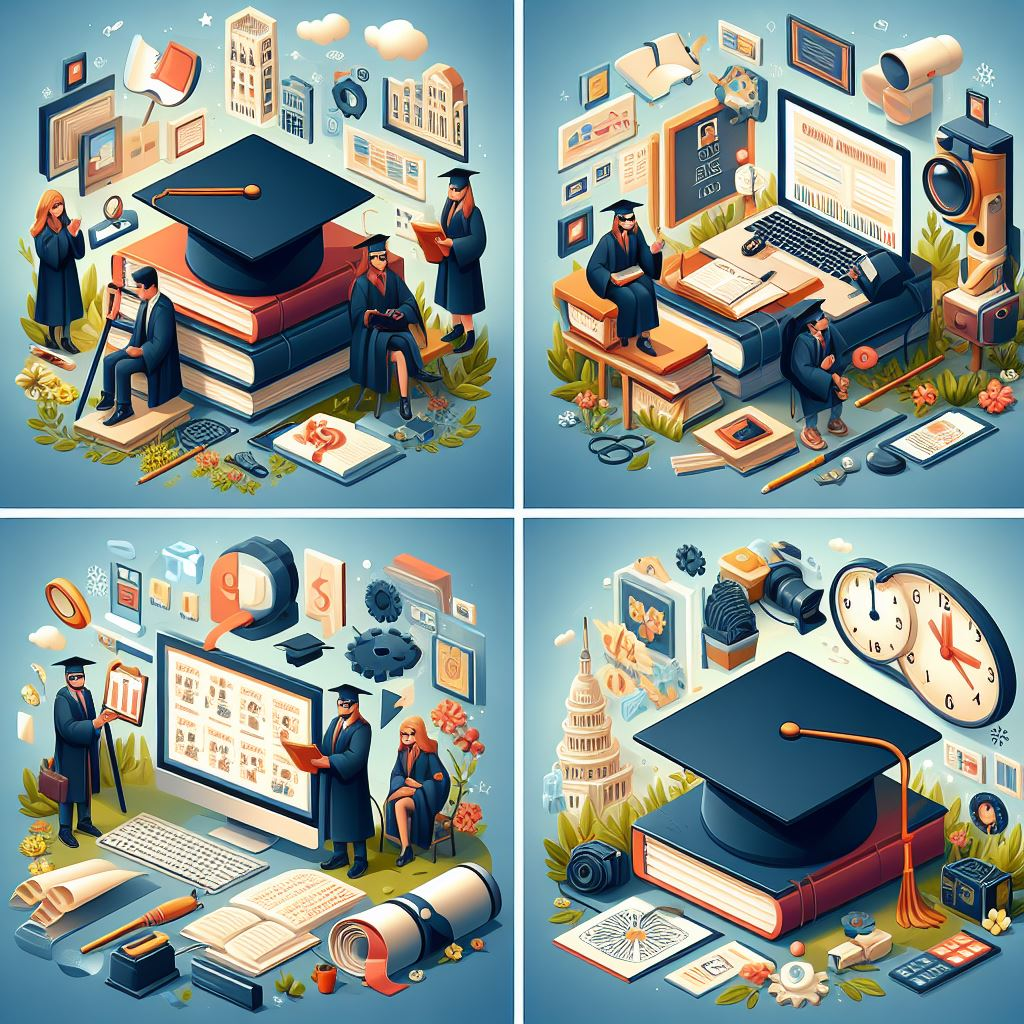

<a id="Import"></a>
<p style="background-color: #1E90FF; font-family: 'Pacifico', cursive; color:#FFD700; font-size:200%; text-align:center; border-radius:3000px 50px;">About Data</p>


**Context:**
This dataset is created for prediction of Graduate Admissions from an Indian perspective.

**Content:**
The dataset contains several parameters which are considered important during the application for Masters Programs. The parameters included are:

- GRE Scores (out of 340)
- TOEFL Scores (out of 120)
- University Rating (out of 5)
- Statement of Purpose and Letter of Recommendation Strength (out of 5)
- Undergraduate GPA (out of 10)
- Research Experience (either 0 or 1)
- Chance of Admit (ranging from 0 to 1)

**Acknowledgements:**
This dataset is inspired by the UCLA Graduate Dataset. The test scores and GPA are in the older format. The dataset is owned by Mohan S Acharya.

**Inspiration:**
This dataset was built with the purpose of helping students in shortlisting universities with their profiles. The predicted output gives them a fair idea about their chances for a particular university.

**Citation:**
Please cite the following if you are interested in using the dataset:
Mohan S Acharya, Asfia Armaan, Aneeta S Antony: A Comparison of Regression Models for Prediction of Graduate Admissions, IEEE International Conference on Computational Intelligence in Data Science 2019

I would like to thank all of you for contributing to this dataset through discussions and questions. I am in awe of the number of kernels built on this dataset. Some results and visualizations are fantastic and make me a proud owner of the dataset. Keep em' coming! Thank You


<a id="Import"></a>
<p style="background-color: #1E90FF; font-family: 'Pacifico', cursive; color:#FFD700; font-size:200%; text-align:center; border-radius:3000px 50px;">About Author</p>


#### **Name :** Muhammad Abdullah 
#### **Social Link :** 

<div style="text-align: left;">
    <table>
        <tr>
            <th><b>Website</b></th>
            <th><b>Links</b></th>
        </tr>
        <tr>
        </tr>
        <tr>
            <td>GitHub</td>
            <td><a href="https://github.com/muhammadabdullah0303"><img src="https://img.shields.io/badge/GitHub-Profile-blue?style=for-the-badge&logo=github" alt="GitHub"/></a></td>
        </tr>
        <tr>
            <td>LinkedIn</td>
            <td><a href="https://www.linkedin.com/in/muhammad-abdullah-6b84b4297/"><img 
                                                                                   src="https://img.shields.io/badge/LinkedIn-Profile-blue?style=for-the-badge&logo=linkedin" alt="LinkedIn"/></a></td>
        </tr>
        <tr>
        </tr>
        <tr>
            <td>Facebook</td>
            <td><a href="https://web.facebook.com/abd.sentaflexmental"><img src="https://img.shields.io/badge/Facebook-Profile-blue?style=for-the-badge&logo=facebook" alt="Facebook"/></a></td>
        </tr>
        <tr>
            <td>Gmail</td>
            <td><a href="mailto:mrabdullah@gmail.com"><img src="https://img.shields.io/badge/Gmail-Contact%20Me-red?style=for-the-badge&logo=gmail" alt="Gmail"/></a></td>
        </tr>
    </table>

<a id="Import"></a>
<p style="background-color: #1E90FF; font-family: 'Pacifico', cursive; color:#FFD700; font-size:200%; text-align:center; border-radius:3000px 50px;">📚 Import Libraries</p>


In [ ]:
# Import Libraries
import pandas as pd 
import optuna
import numpy as np 
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns 
import math
from colorama import Fore, Style, init;
# Import necessary libraries
from IPython.display import display, HTML
from scipy.stats import skew  # Import the skew function
# Import Plotly.go
import plotly.graph_objects as go
# import Subplots
from plotly.subplots import make_subplots
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")
# Model Classifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingClassifier, VotingRegressor
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler , StandardScaler , QuantileTransformer
from sklearn.model_selection import cross_val_score
from sklearn.metrics import *
# Classifier 
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from lightgbm import LGBMClassifier
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
# Regressor 
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, ExtraTreesRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

# Paellete
# palette = ["#00B1D2FF", "#FDDB27FF"]
palette = ['#D7A9E3FF', '#8BBEE8FF', '#A8D5BAFF']
color_palette = sns.color_palette(palette)
# Set the option to display all columns
pd.set_option('display.max_columns', None)
print_boxed_zigzag_heading(' Setup Intilized ')

<a id="Import"></a>
<p style="background-color: #1E90FF; font-family: 'Pacifico', cursive; color:#FFD700; font-size:200%; text-align:center; border-radius:3000px 50px;">Load Data and Overview</p>
​

In [ ]:
# Load Data 
tr_d = pd.read_csv('/kaggle/input/graduate-admissions/Admission_Predict_Ver1.1.csv')
print_boxed_zigzag_heading('Data Loaded')

In [ ]:
# Function 4 Data Overview
def print_boxed_blue_heading(heading):
    gradient = [Fore.BLUE, Fore.CYAN, Fore.GREEN, Fore.YELLOW, Fore.RED, Fore.MAGENTA]
    print("\n" + "=" * (len(heading) + 20))
    words = heading.split()
    for i, word in enumerate(words):
        if i == len(words) - 1:
            print(f"| {gradient[len(word) % len(gradient)] + word + Style.RESET_ALL} |")
        else:
            print(f"| {gradient[len(word) % len(gradient)] + word + Style.RESET_ALL}", end=" ")
    print("=" * (len(heading) + 20))
def print_boxed_zigzag_heading(heading):
    gradient = [Fore.BLUE, Fore.CYAN, Fore.GREEN, Fore.YELLOW, Fore.RED, Fore.MAGENTA]
    print("\n" + f"{Fore.YELLOW}" + "╭" + "─" * (len(heading) + 20) + "╮" + Style.RESET_ALL)  # Change line color to yellow
    words = heading.split()
    for i, word in enumerate(words):
        if i == len(words) - 1:
            print(f"{Fore.CYAN}│ {word} │" + Style.RESET_ALL) 
        else:
            print(f"{gradient[len(word) % len(gradient)]}│ {word}", end=" ")
    print(f"{Fore.YELLOW}" + "╰" + "─" * (len(heading) + 20) + "╯" + Style.RESET_ALL) 
    
# Load Data and Make DataFrame
def L_Data(directory_TR,directory_TE):
    filepath_TR =[]
    label_TR = []

    folds_TR = os.listdir(directory_TR)

    for fold in folds_TR:
        f_path_TR = os.path.join(directory_TR , fold)

        imgs_TR = os.listdir(f_path_TR)

        for img in imgs_TR:

            img_path_TR = os.path.join(f_path_TR , img)
            filepath_TR.append(img_path_TR)
            label_TR.append(fold)

    #Concat data paths with labels
    file_path_series_TR = pd.Series(filepath_TR , name= 'filepath')
    Label_path_series_TR = pd.Series(label_TR , name = 'label')
    df_train = pd.concat([file_path_series_TR ,Label_path_series_TR ] , axis = 1)
    
    filepath_TE =[]
    label_TE = []

    folds_TE = os.listdir(directory_TE)

    for fold in folds_TE:
        f_path_TE = os.path.join(directory_TE , fold)

        imgs_TE = os.listdir(f_path_TE)

        for img in imgs_TE:

            img_path_TE = os.path.join(f_path_TE , img)
            filepath_TE.append(img_path_TE)
            label_TE.append(fold)

    #Concat data paths with labels
    file_path_series_TE = pd.Series(filepath_TE , name= 'filepath')
    Label_path_series_TE = pd.Series(label_TE , name = 'label')
    df_test = pd.concat([file_path_series_TE ,Label_path_series_TE ] , axis = 1)   
    
    # Display head of the training dataset nicely
    print_boxed_zigzag_heading('Train Data')
    print_boxed_blue_heading(f"The Head Of Train Dataset is:")
    display(HTML(df_train.head(5).to_html(index=False).replace('<table border="1" class="dataframe">', '<table style="border: 2px solid blue;">').replace('<td>', '<td style="color: skyblue;">')))
    print('\n')

    # Display tail of the training dataset nicely
    print_boxed_blue_heading("The Tail Of Train Dataset is:")
    display(HTML(df_train.tail(5).to_html(index=False).replace('<table border="1" class="dataframe">', '<table style="border: 2px solid blue;">').replace('<td>', '<td style="color: skyblue;">')))
    print('\n')

    print_boxed_blue_heading(f'The Shape of the Train Data is {df_train.shape} |')
    print_boxed_blue_heading(f'- 1.The No of Rows is {df_train.shape[0]} |')
    print_boxed_blue_heading(f'- 2.The No of Cols is {df_train.shape[1]}|')

    print('\n')
    
    # Display head of the training dataset nicely
    print_boxed_zigzag_heading('Test Data')
    print_boxed_blue_heading(f"The Head Of Test Dataset is:")
    display(HTML(df_test.head(5).to_html(index=False).replace('<table border="1" class="dataframe">', '<table style="border: 2px solid blue;">').replace('<td>', '<td style="color: skyblue;">')))
    print('\n')

    # Display tail of the training dataset nicely
    print_boxed_blue_heading("The Tail Of Test Dataset is:")
    display(HTML(df_test.tail(5).to_html(index=False).replace('<table border="1" class="dataframe">', '<table style="border: 2px solid blue;">').replace('<td>', '<td style="color: skyblue;">')))
    print('\n')

    print_boxed_blue_heading(f'The Shape of the Test Data is {df_test.shape} |')
    print_boxed_blue_heading(f'- 1.The No of Rows is {df_test.shape[0]} |')
    print_boxed_blue_heading(f'- 2.The No of Cols is {df_test.shape[1]}|')

    print('\n')
    
    return df_train , df_test
print_boxed_zigzag_heading('Load Data Function Intilized ')

In [ ]:
# Data Overview
data_overview(tr_d)

In [ ]:
# Drop Irrelevent column
tr_d.drop(columns='Serial No.',inplace=True)
print_boxed_zigzag_heading('Column Dropped')

<a id="Import"></a>
<p style="background-color: #1E90FF; font-family: 'Pacifico', cursive; color:#FFD700; font-size:200%; text-align:center; border-radius:3000px 50px;">Numerical Distribution</p>

In [ ]:
# Function to Plot Hist and Box
def plot_histograms_and_boxplots(data, columns, color='#1E90FF'):
    num_plots = len(columns)
    fig, axes = plt.subplots(num_plots, 2, figsize=(15, num_plots*5))
    
    for i, col in enumerate(columns):
        sns.histplot(data[col], ax=axes[i, 0], color=color)
        axes[i, 0].set_title(f'Histogram of {col}')
        
        sns.boxplot(data[col], ax=axes[i, 1], color=color)
        axes[i, 1].set_title(f'Boxplot of {col}')
        
    plt.tight_layout()
    plt.show()
    
# Plot 
plot_histograms_and_boxplots(tr_d,tr_d.columns)

<a id="Import"></a>
<p style="background-color: #1E90FF; font-family: 'Pacifico', cursive; color:#FFD700; font-size:200%; text-align:center; border-radius:3000px 50px;">Correlation Matrix</p>

In [ ]:
#Correlation
print_boxed_zigzag_heading('Correlation Matrix DF')
plt.figure(figsize=(20, 10))
sns.heatmap(tr_d.corr(), annot=True, cmap='Blues')
plt.show()

<a id="Import"></a>
<p style="background-color: #1E90FF; font-family: 'Pacifico', cursive; color:#FFD700; font-size:200%; text-align:center; border-radius:3000px 50px;">Ann Model Building</p>

In [ ]:
# # # =================================================================================================================
# # #                         X < y 
# # #================================================================================================================== 
X_T = tr_d.drop('Chance of Admit ', axis=1)
y_T = tr_d['Chance of Admit ']
# # # =================================================================================================================
# # #                         Train < Test Split
# # #================================================================================================================== 
X_TR, X_TE, Y_TR, Y_TE = train_test_split(X_T, y_T, test_size=0.1, random_state=42)

# # # =================================================================================================================
# # #                         Shapes < 
# # #================================================================================================================== 
print_boxed_zigzag_heading('Data Splitted Done !')
print_boxed_zigzag_heading(f"Training set shape - X: {X_TR.shape}, y: {Y_TR.shape}")
print_boxed_zigzag_heading(f"Testing set shape - X: {X_TE.shape}, y: {Y_TE.shape}")

In [ ]:
# Scale data 
sc = MinMaxScaler()
X_TR = sc.fit_transform(X_TR)
X_TE = sc.transform(X_TE)
print_boxed_zigzag_heading('Data Scaled Done !')

<a id="Import"></a>
<p style="background-color: #1E90FF; font-family: 'Pacifico', cursive; color:#FFD700; font-size:200%; text-align:center; border-radius:3000px 50px;">Base Classifiers</p>

In [ ]:
# Initlize Models
# Support Vector Machine
svr = SVR(kernel='sigmoid', gamma=1.0)
# KNeighbours 
knr = KNeighborsRegressor()
# Decision Tree 
dtr = DecisionTreeRegressor(random_state=42)
# Logistic Regression
lrr = LogisticRegression(solver='liblinear', penalty='l1')
# Random Forest Regressor
rfr = RandomForestRegressor(n_estimators=100, random_state=42)
# AddaBoost Regressor
abr = AdaBoostRegressor(n_estimators=100, random_state=42)
# Extra Tree Regressor a Ensemble Method
etr = ExtraTreesRegressor(n_estimators=100, random_state=42)
# XGB Regressor
xgbr = XGBRegressor(n_estimators=100, random_state=42)
# CatBoost Regressor
catboost_params = {
    'iterations': 100,
    'random_state': 42,
    'verbose': 0,
}
catboost_regressor = CatBoostRegressor(**catboost_params)
# LightGBM Regressor
lgbm_params = {
    'n_estimators': 890,
    'learning_rate': 0.7019434172842792,
    'max_depth': 19,
    'reg_alpha': 1.2057738033316066,
    'reg_lambda': 0.18598174484559382,
    'num_leaves': 3,
    'subsample': 0.746154395882518,
    'colsample_bytree': 0.3877680559022922
}
lgbm_regressor = LGBMRegressor(**lgbm_params, random_state=42)

#___________________________________________________________________
print_boxed_zigzag_heading('Hurry ! Base Regressors Are Intilized')

<a id="Import"></a>
<p style="background-color: #1E90FF; font-family: 'Pacifico', cursive; color:#FFD700; font-size:200%; text-align:center; border-radius:3000px 50px;">Fit Base Classifiers</p>

In [ ]:
# Fitting Each Model One by One 
# 2. KNeighbours
knr.fit(X_TR ,Y_TR)
# Pred 
knnr_pred = knr.predict(X_TE)
#-----------------------------
# 4. Decision Tree
dtr.fit(X_TR ,Y_TR)
# Pred 
dtr_pred = dtr.predict(X_TE)
#-----------------------------
# 6. Random Forest Regressor
rfr.fit(X_TR ,Y_TR)
# Pred 
rfr_pred = rfr.predict(X_TE)
#-----------------------------
# 7. AddaBoost Regressor
abr.fit(X_TR ,Y_TR)
# Pred 
abr_pred = abr.predict(X_TE)
#-----------------------------
# 8. Extra Tree Regressor a Ensemble Method
etr.fit(X_TR ,Y_TR)
# Pred 
etr_pred = etr.predict(X_TE)
#-----------------------------
# 9. XGB Regressor
xgbr.fit(X_TR ,Y_TR)
# Pred 
xgbr_pred = xgbr.predict(X_TE)
#-----------------------------
# 10. CatBoost Regressor
catboost_regressor.fit(X_TR, Y_TR)
# Pred
catboost_regressor_pred = catboost_regressor.predict(X_TE)
#-----------------------------
# 11. LightGBM Regressor
lgbm_regressor.fit(X_TR, Y_TR)
# Pred
lgbm_regressor_pred = lgbm_regressor.predict(X_TE)
#-----------------------------
print_boxed_zigzag_heading('Hurry ! Models Are Fitted')

<a id="Import"></a>
<p style="background-color: #1E90FF; font-family: 'Pacifico', cursive; color:#FFD700; font-size:200%; text-align:center; border-radius:3000px 50px;">Evaluate Base Classifiers</p>

In [ ]:
# KNN
r2_KNN = r2_score(Y_TE, knnr_pred)
mse_KNN = mean_squared_error(Y_TE, knnr_pred)
print_boxed_zigzag_heading("Evaluation Results for KNN")
PrintColor(f"The R2 Score Of KNN is {r2_KNN}, MSE is {mse_KNN}")
print("\n")

# Decision Tree
r2_DTC = r2_score(Y_TE, dtr_pred)
mse_DTC = mean_squared_error(Y_TE, dtr_pred)
print_boxed_zigzag_heading("Evaluation Results for Decision Tree")
PrintColor(f"The R2 Score Of Decision Tree is {r2_DTC}, MSE is {mse_DTC}")
print("\n")

# Random Forest Classifier
r2_RF = r2_score(Y_TE, rfr_pred)
mse_RF = mean_squared_error(Y_TE, rfr_pred)
print_boxed_zigzag_heading("Evaluation Results for Random Forest Classifier")
PrintColor(f"The R2 Score Of Random Forest Classifier is {r2_RF}, MSE is {mse_RF}")
print("\n")

# AdaBoost Classifier
r2_ABC = r2_score(Y_TE, abr_pred)
mse_ABC = mean_squared_error(Y_TE, abr_pred)
print_boxed_zigzag_heading("Evaluation Results for AdaBoost Classifier")
PrintColor(f"The R2 Score Of AdaBoost Classifier is {r2_ABC}, MSE is {mse_ABC}")
print("\n")

# Extra Tree Classifier
r2_ETC = r2_score(Y_TE, etr_pred)
mse_ETC = mean_squared_error(Y_TE, etr_pred)
print_boxed_zigzag_heading("Evaluation Results for Extra Tree Classifier")
PrintColor(f"The R2 Score Of Extra Tree Classifier is {r2_ETC}, MSE is {mse_ETC}")
print("\n")

# XGB Classifier
r2_XGB = r2_score(Y_TE, xgbr_pred)
mse_XGB = mean_squared_error(Y_TE, xgbr_pred)
print_boxed_zigzag_heading("Evaluation Results for XGB Classifier")
PrintColor(f"The R2 Score Of XGB Classifier is {r2_XGB}, MSE is {mse_XGB}")
print("\n")

# CatBoost Classifier
r2_Cat = r2_score(Y_TE, catboost_regressor_pred)
mse_Cat = mean_squared_error(Y_TE, catboost_regressor_pred)
print_boxed_zigzag_heading("Evaluation Results for CatBoost Classifier")
PrintColor(f"The R2 Score Of CatBoost Classifier is {r2_Cat}, MSE is {mse_Cat}")
print("\n")

# LightGBM Classifier
r2_LGBM = r2_score(Y_TE, lgbm_regressor_pred)
mse_LGBM = mean_squared_error(Y_TE, lgbm_regressor_pred)
print_boxed_zigzag_heading("Evaluation Results for LightBoost Classifier")
PrintColor(f"The R2 Score Of LightGBM Classifier is {r2_LGBM}, MSE is {mse_LGBM}")
print("\n")

In [ ]:
# Create a dictionary with evaluation results
evaluation_data = {
    'Model': ['KNN', 'Decision Tree', 'Random Forest', 'AdaBoost', 'Extra Tree', 'XGBoost', 'CatBoost', 'LightGBM'],
    'R2 Score': [r2_KNN, r2_DTC, r2_RF, r2_ABC, r2_ETC, r2_XGB, r2_Cat, r2_LGBM],
    'Mean Squared Error': [mse_KNN, mse_DTC, mse_RF, mse_ABC, mse_ETC, mse_XGB, mse_Cat, mse_LGBM]
}

# Create a dataframe
evaluation_df = pd.DataFrame(evaluation_data)

# Sort the dataframe based on R2 Score and Mean Squared Error columns in descending order
evaluation_df = evaluation_df.sort_values(by=['R2 Score', 'Mean Squared Error'], ascending=False)

# Display the sorted dataframe
print_boxed_zigzag_heading('Data Frame')
evaluation_df

In [ ]:
print_boxed_zigzag_heading("The LGBMClassifier is Performing Outstand")

<a id="Import"></a>
<p style="background-color: #1E90FF; font-family: 'Pacifico', cursive; color:#FFD700; font-size:200%; text-align:center; border-radius:3000px 50px;">The End</p>